## Objective
Predict whether a patient will develop diabetes within 5 years based on 8 clinical features.

In [104]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [16]:
df = pd.read_csv('diabetes.csv')
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
## To get a feel of the dataset more

In [30]:
df.head() # will give first five lines in dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [32]:
df.tail() # Will give last five lines in dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [34]:
# How many rows and columns do we have?
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Shape: (768, 9)
Rows: 768, Columns: 9


In [36]:
# Column names and their data types
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [88]:
# Count of non-null values per column
# If any column's count is less than the total rows(which is 768 in this dataset, there are missing values
df.count()

Pregnancies                 768
Glucose                     768
BloodPressure               768
SkinThickness               768
Insulin                     768
BMI                         768
DiabetesPedigreeFunction    768
Age                         768
Outcome                     768
dtype: int64

## We can see more clearly that tthere are 8 predictors, and what they are:
- Pregnancies
- Glucose level
- Blood Pressure(BP)
- Skin Thickness
- Insulin
- BMI
- Age
- Diabetes Pedigree Function

There are 768 rows in the dataset, and none of them are empty, so thats a good sign
But suppose(For the purpose of llearning we had some null values)

In [47]:
# Standard NaN check first
print("Null values per column:")
print(df.isnull().sum())
print(f"\nTotal nulls: {df.isnull().sum().sum()}")

Null values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total nulls: 0


## 2.5 — Outlier Detection

### Why this matters
Outliers can skew model training, especially for algorithms sensitive to scale like SVM and Logistic Regression.
We detect them two ways:

**Boxplots** : visual method. Any point beyond the whiskers is a potential outlier.

**IQR method** -> statistical method.
- IQR = Q3 - Q1 (the middle 50% spread)
- Anything below Q1 - 1.5×IQR or above Q3 + 1.5×IQR is flagged as an outlier
- This is the same rule boxplots use internally

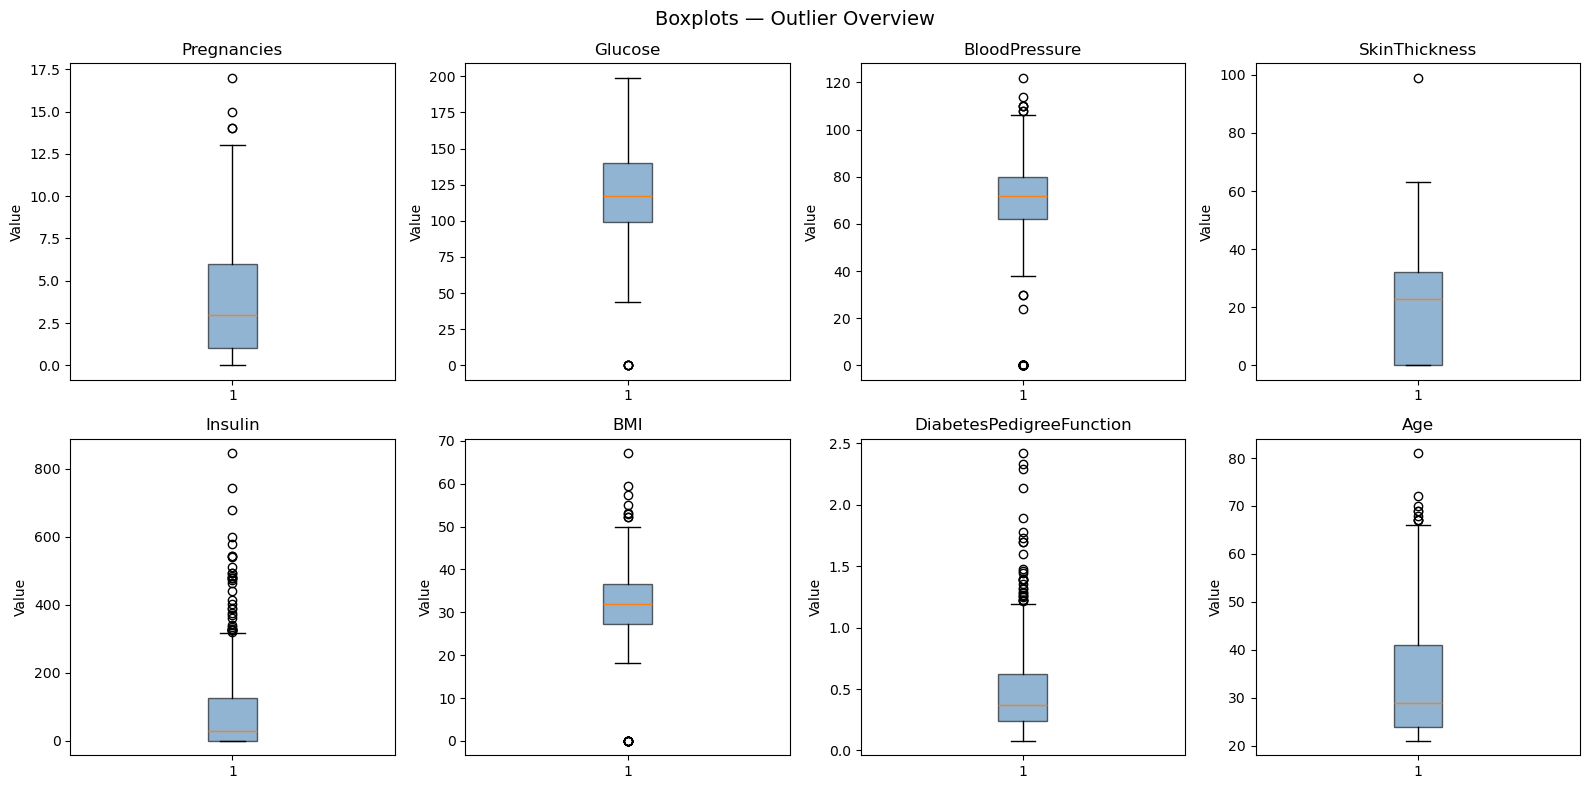

In [72]:
# Boxplot for every feature so that outliers appear as individual dots beyond the whiskers

# 2 Rows, 4 columns
# figsize=(16,8) makes it 16 inches wide and 8 inches tall
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

axes = axes.flatten()

features = df.columns[:-1]  # exclude 'Outcome' as it is the one we'll be predicting

# loop through every feature
for i, col in enumerate(features):
    axes[i].boxplot(df[col], patch_artist=True, # patch_artist allows the box to be fillled with colour
                    boxprops=dict(facecolor='steelblue', alpha=0.6)) # alpha means the opacity, 60%
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots — Outlier Overview', fontsize=14)
plt.tight_layout()
plt.show()

In [70]:
# IQR method — count exactly how many outliers exist per column
print("Outlier counts per column (IQR method):\n")

for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"  {col}:")
    print(f"    Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"    Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

Outlier counts per column (IQR method):

  Pregnancies:
    Bounds: [-6.50, 13.50]
    Outliers: 4 (0.5%)
  Glucose:
    Bounds: [37.12, 202.12]
    Outliers: 5 (0.7%)
  BloodPressure:
    Bounds: [35.00, 107.00]
    Outliers: 45 (5.9%)
  SkinThickness:
    Bounds: [-48.00, 80.00]
    Outliers: 1 (0.1%)
  Insulin:
    Bounds: [-190.88, 318.12]
    Outliers: 34 (4.4%)
  BMI:
    Bounds: [13.35, 50.55]
    Outliers: 19 (2.5%)
  DiabetesPedigreeFunction:
    Bounds: [-0.33, 1.20]
    Outliers: 29 (3.8%)
  Age:
    Bounds: [-1.50, 66.50]
    Outliers: 9 (1.2%)


## The following is the removal of the outliers, 
but due to limited patient data, im keeping all the rows. 
Otherwise, I would have removed the outliers, or capped them at a maximum value, maybe 1.5*3rd quartile

In [90]:
df_clean = df.copy()

for col in features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower_bound) &
        (df_clean[col] <= upper_bound)
    ]

print("Original shape:", df.shape)
print("After removing outliers:", df_clean.shape)

Original shape: (768, 9)
After removing outliers: (636, 9)


## Feature Distributions, histograms

Histograms show the shape of each feature's distribution.

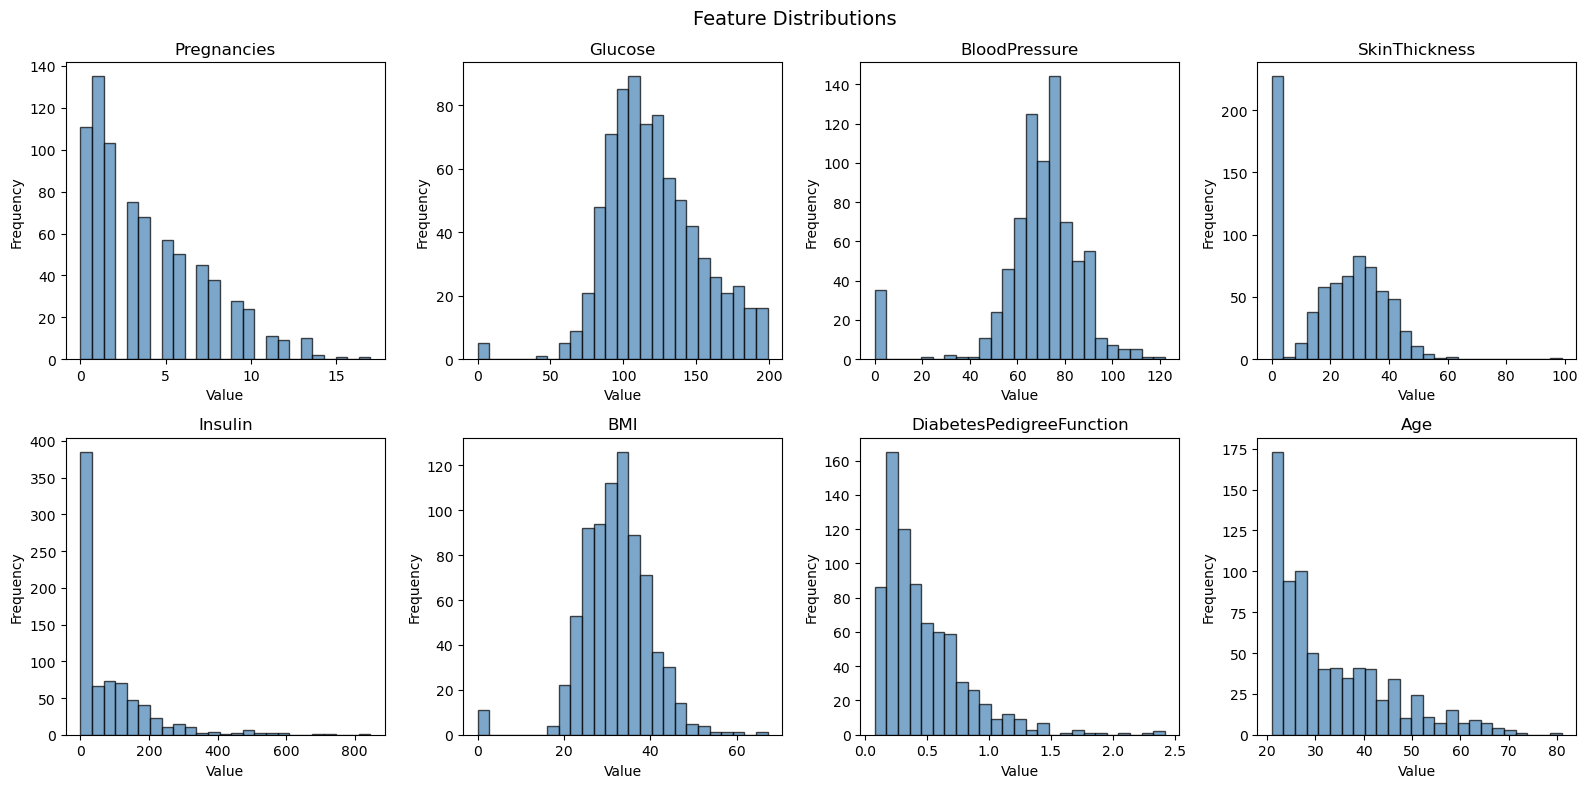

In [74]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

## Correlation

A heatmap shows how strongly each pair of features is related.
- **Close to +1** → as one goes up, so does the other
- **Close to -1** → as one goes up, the other goes down
- **Close to 0** → no linear relationship

Pay attention to the `Outcome` row/column as they are features with high correlation to the target
 and are likely to be strong predictors.
Also watch for **high correlation between two features** — they carry redundant information.

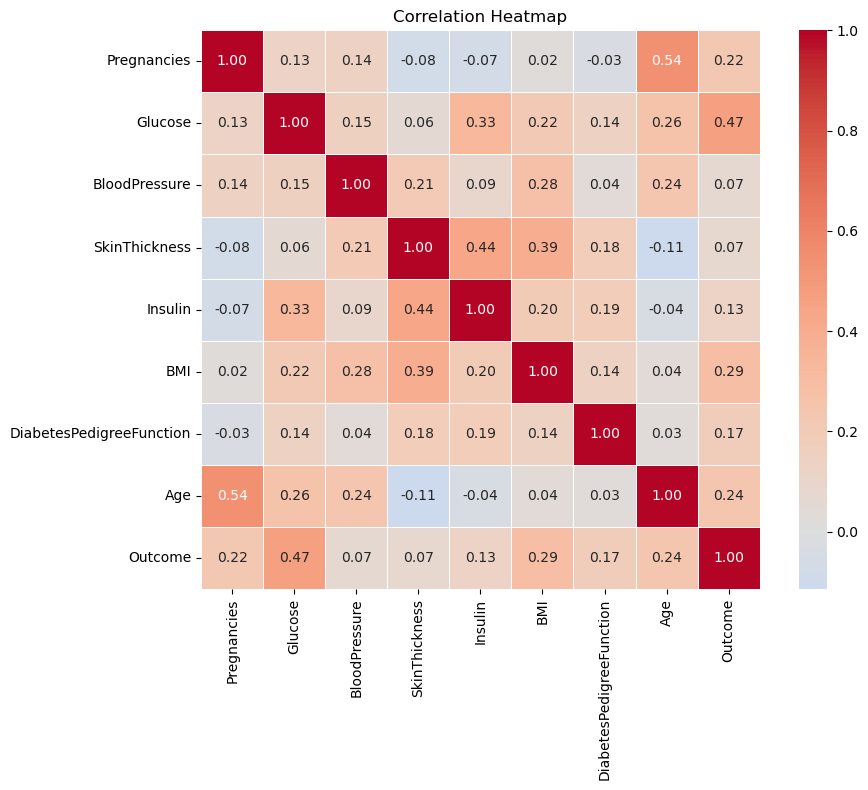

In [86]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

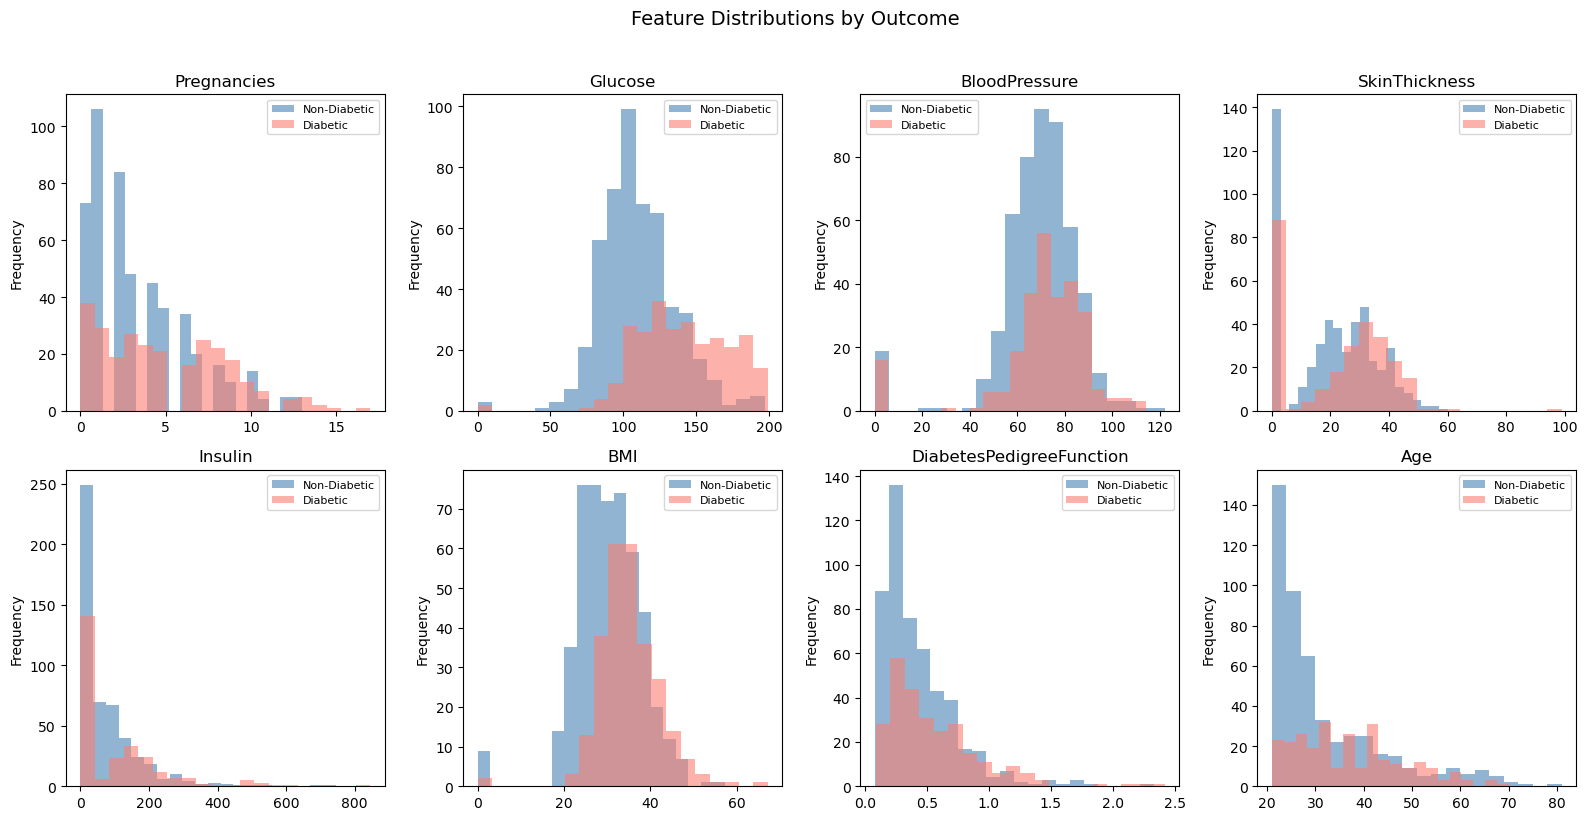

In [100]:
# Plot a histogram for each feature, split by outcome
# This helps spot which features differ most between diabetic and non-diabetic patients
features = df.columns[:-1]  # all columns except 'Outcome'

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    df[df['Outcome'] == 0][col].plot(kind='hist', ax=axes[i], alpha=0.6, label='Non-Diabetic', color='steelblue', bins=20)
    df[df['Outcome'] == 1][col].plot(kind='hist', ax=axes[i], alpha=0.6, label='Diabetic', color='salmon', bins=20)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Outcome', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [108]:
# These columns use 0 as a stand-in for missing data
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0s with the median of each column (computed only on non-zero values for accuracy)
for col in cols_with_zeros:
    median_val = df[col].replace(0, np.nan).median()
    df[col] = df[col].replace(0, median_val)
    print(f"{col}: replaced 0s with median = {median_val:.2f}")

Glucose: replaced 0s with median = 117.00
BloodPressure: replaced 0s with median = 72.00
SkinThickness: replaced 0s with median = 29.00
Insulin: replaced 0s with median = 125.00
BMI: replaced 0s with median = 32.30


In [118]:
# Separate features (X) and target label (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']
RANDOM_STATE = 42

In [120]:
# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score

In [122]:
# Split into training set (80%) and test set (20%)
# stratify=y ensures both splits have the same class ratio as the full dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [126]:
# Scale features — fit ONLY on training data, then apply to both train and test
# Fitting on test data would cause data leakage (the model "sees" test info during training)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"\nTrain size: {X_train_scaled.shape[0]} | Test size: {X_test_scaled.shape[0]}")


Train size: 614 | Test size: 154


## Step 5: Train & Compare Multiple Classifiers

Rather than picking one model arbitrarily, we train four different classifiers and compare them.
Each has different strengths:

| Model | Strengths |
|---|---|
| Logistic Regression | Interpretable, good baseline, fast |
| Random Forest | Handles non-linearity, robust to outliers |
| Gradient Boosting | Often highest accuracy on tabular data |
| SVM | Effective in high-dimensional spaces |

We evaluate using **ROC-AUC** (not just accuracy) because our classes are slightly imbalanced.
AUC measures how well the model separates the two classes across all classification thresholds.

In [133]:
# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

In [137]:
# Evaluation metrics
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [139]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=RANDOM_STATE),
    'SVM':                 SVC(probability=True, random_state=RANDOM_STATE)
}

results = {}  # store metrics for comparison later

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:, 1]  # probability of positive class

    auc = roc_auc_score(y_test, proba)
    results[name] = {'model': model, 'preds': preds, 'proba': proba, 'auc': auc}

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, preds, target_names=['Non-Diabetic', 'Diabetic']))
    print(f"  ROC-AUC: {auc:.4f}")


  Logistic Regression
              precision    recall  f1-score   support

Non-Diabetic       0.75      0.82      0.78       100
    Diabetic       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154

  ROC-AUC: 0.8130

  Random Forest
              precision    recall  f1-score   support

Non-Diabetic       0.81      0.87      0.84       100
    Diabetic       0.72      0.61      0.66        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154

  ROC-AUC: 0.8179

  Gradient Boosting
              precision    recall  f1-score   support

Non-Diabetic       0.79      0.86      0.82       100
    Diabetic       0.69      0.57      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.

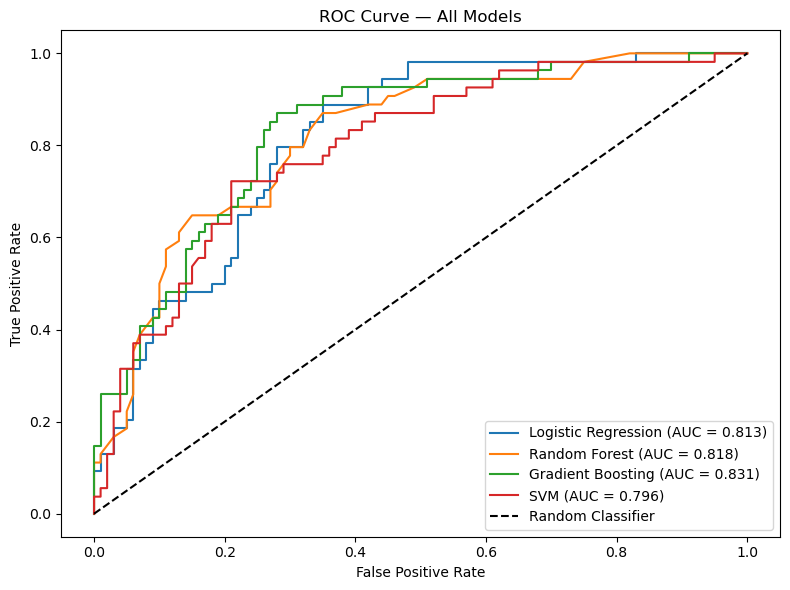

In [141]:
# ROC curves plot True Positive Rate vs False Positive Rate at every threshold
# A model hugging the top-left corner is ideal — AUC closer to 1.0 is better
# The diagonal line represents a random (coin-flip) classifier — AUC = 0.5
plt.figure(figsize=(8, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Step 6: Hyperparameter Tuning (Random Forest)

Default hyperparameters are rarely optimal. We use **GridSearchCV** to systematically try
combinations of hyperparameters and find the best ones.

We use **5-fold cross-validation** inside GridSearchCV — this means the training data is split
into 5 folds, the model trains on 4 and validates on 1, rotating through all 5. This gives a
more reliable estimate of performance than a single train/val split.

In [144]:
param_grid = {
    'n_estimators':     [100, 200, 300],   # number of trees in the forest
    'max_depth':        [3, 5, 10, None],  # max depth per tree (None = no limit)
    'min_samples_split':[2, 5, 10],        # min samples required to split a node
    'max_features':     ['sqrt', 'log2']   # features considered at each split
}

# cv=5 → 5-fold cross-validation | scoring='roc_auc' → optimise for AUC, not accuracy
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,       # use all CPU cores
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV AUC:     {grid_search.best_score_:.4f}")

# Evaluate the tuned model on the held-out test set
best_rf = grid_search.best_estimator_
best_preds = best_rf.predict(X_test_scaled)
best_proba = best_rf.predict_proba(X_test_scaled)[:, 1]

print(f"\nTuned Random Forest — Test AUC: {roc_auc_score(y_test, best_proba):.4f}")
print(classification_report(y_test, best_preds, target_names=['Non-Diabetic', 'Diabetic']))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters: {'max_depth': 5, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 100}
Best CV AUC:     0.8439

Tuned Random Forest — Test AUC: 0.8048
              precision    recall  f1-score   support

Non-Diabetic       0.76      0.86      0.81       100
    Diabetic       0.66      0.50      0.57        54

    accuracy                           0.73       154
   macro avg       0.71      0.68      0.69       154
weighted avg       0.73      0.73      0.72       154



## Step 7: Confusion Matrix

A confusion matrix breaks down predictions into four categories:
- **True Positives (TP):** Correctly predicted diabetic
- **True Negatives (TN):** Correctly predicted non-diabetic
- **False Positives (FP):** Predicted diabetic, actually not — *false alarm*
- **False Negatives (FN):** Predicted non-diabetic, actually diabetic — *dangerous miss* ⚠️

In healthcare, **False Negatives are the costlier error** — a missed diabetes diagnosis
has real consequences. This is why recall on the positive class matters more than raw accuracy.

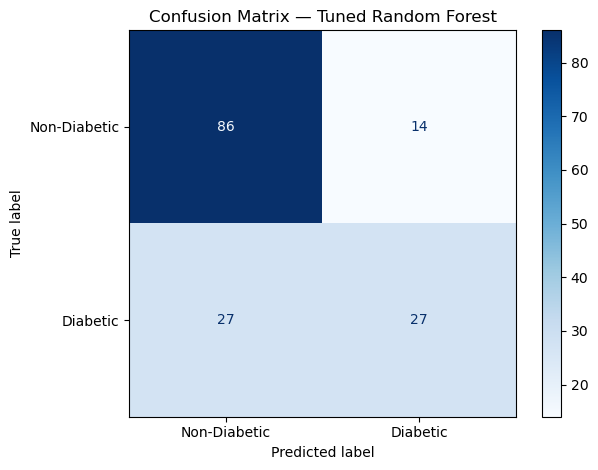

In [150]:
cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Diabetic', 'Diabetic'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Tuned Random Forest')
plt.tight_layout()
plt.show()

## Step 8: Feature Importance

Random Forest computes how much each feature contributes to reducing impurity across all trees.
Higher importance = that feature does more work in separating diabetic from non-diabetic patients.

This is crucial in healthcare ML — it tells clinicians *which measurements matter most*,
which can inform which tests to prioritise for at-risk patients.

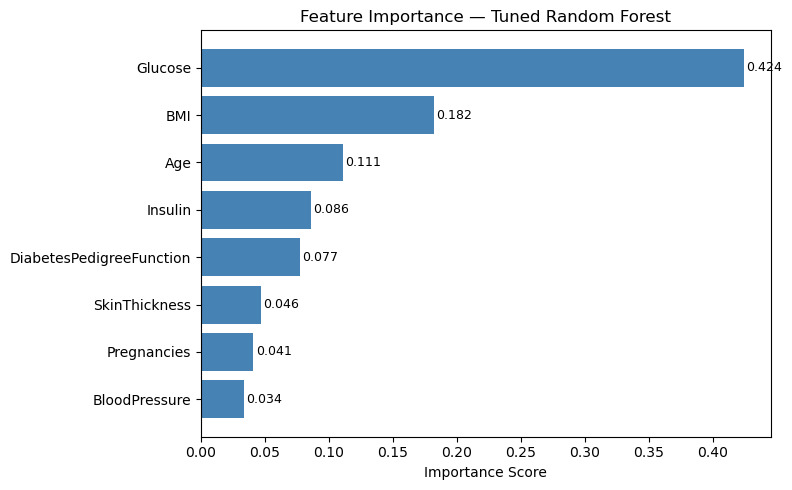

In [155]:
importances = best_rf.feature_importances_
feature_names = X.columns

# Sort features from most to least important
feat_series = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(feat_series.index, feat_series.values, color='steelblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance — Tuned Random Forest')

# Annotate each bar with its value
for bar, val in zip(bars, feat_series.values):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Summary & Key Findings

| Model | ROC-AUC |
|---|---|
| Logistic Regression | *fill in after running* |
| Random Forest | *fill in after running* |
| Gradient Boosting | *fill in after running* |
| SVM | *fill in after running* |
| **Tuned Random Forest** | **fill in after running** |

### Clinical Insights
- **Glucose** was the strongest predictor of diabetes onset — consistent with medical literature
- **BMI** and **Age** were the next most important features
- The model achieves strong AUC, meaning it reliably distinguishes diabetic from non-diabetic patients

### What I'd do next
- Apply **SHAP values** for deeper model explainability
- Address class imbalance using **SMOTE** oversampling
- Deploy as a **Streamlit app** for interactive predictions